<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Clase08_Actividad_RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 10.8 MB/s eta 0:00:00


In [2]:
import cv2 # La vamos a usar para Selective Search, dibujar las cajas y manipular pixeles.
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions # Modelo VGG16 y utilidades.
from tensorflow.keras.preprocessing import image # Cargar y transformar imagenes en objetos compatibles con la red.
from tensorflow.keras.models import Model # Permite manipular la estructura de los modelos.

# cv2_imshow es la forma recomendada de mostrar imagenes dentro de Colab
from google.colab.patches import cv2_imshow

In [3]:
# Cargamos el modelo con los pesos de 'imagenet' para que ya sepa reconocer objetos desde el inicio.
modelo_base = VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
imagen_original = cv2.imread('naranja-manzana.jpg')

# Convertimos de BGR a RGB porque VGG16 trabaja en RGB
imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

# Inicializamos el algoritmo Selective Search
busqueda_selectiva = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

# Le pasamos la imagen original al algoritmo para que empiece a analizarla.
busqueda_selectiva.setBaseImage(imagen_original)

# Activamos el modo 'Fast' (Rapido): reduce la precision pero acelera la obtencion de propuestas.
busqueda_selectiva.switchToSelectiveSearchFast()

# Ejecutamos el proceso: nos devuelve una lista de coordenadas [x, y, ancho, alto].
# Cada rectangulo es una "Region de Interes" (RoI) que luego la CNN debe validar.
rectangulos_propuestos = busqueda_selectiva.process()

print(f"Se encontraron {len(rectangulos_propuestos)} regiones candidatas.")

Se encontraron 581 regiones candidatas.


In [5]:
# UMBRAL: solo dibujamos detecciones con mas de 95% de confianza (consigna de la actividad)
UMBRAL_CONFIANZA = 0.95

# CAPA DE VISUALIZACION: trabajamos sobre una COPIA para no modificar la imagen original.
# Usamos la version BGR porque cv2_imshow espera BGR para mostrar bien los colores.
imagen_detecciones = imagen_original.copy()

# Contador de objetos efectivamente dibujados
objetos_detectados = 0

# R-CNN es lenta porque debe pasar cada region por la CNN. Solo vamos a pasar 50 RoI.
for i in range(50):

    # Obtenemos origen (x,y) y dimensiones (ancho, alto) de la region propuesta
    x, y, w, h = rectangulos_propuestos[i]

    # Extraemos el area de interes (RoI) recortando segun el rango vertical y horizontal.
    recorte = imagen_rgb[y:y+h, x:x+w]

    # WARPING: redimensionamos forzosamente al tamano que espera la VGG16 (224x224)
    recorte_redimensionado = cv2.resize(recorte, (224, 224))

    # Las redes esperan un batch de imagenes: (224,224,3) -> (1,224,224,3)
    matriz_foto = np.expand_dims(recorte_redimensionado, axis=0)

    # Normalizamos segun lo que espera VGG16
    datos_listos = preprocess_input(matriz_foto)

    # Pasamos la imagen a la CNN: devuelve un vector de probabilidades para las 1.000 clases.
    prediccion = modelo_base.predict(datos_listos, verbose=0)

    # Traducimos el vector a palabra y nos quedamos con la opcion mas probable (top=1).
    resultado = decode_predictions(prediccion, top=1)[0][0]
    etiqueta = resultado[1]   # Nombre del objeto (clase)
    confianza = resultado[2]  # Seguridad de la red (0 a 1)

    # FILTRO DE CONFIANZA: solo dibujamos si la red esta muy segura (> 95%).
    # Todo lo que dibujamos y contamos va ADENTRO de este if.
    if confianza > UMBRAL_CONFIANZA:
        objetos_detectados += 1

        # Color aleatorio por deteccion para diferenciar cajas solapadas (formato BGR)
        color = (int(np.random.randint(0, 255)),
                 int(np.random.randint(0, 255)),
                 int(np.random.randint(0, 255)))

        # IDENTIFICACION ESPACIAL: cv2.rectangle dibuja la caja delimitadora.
        # Parametros: imagen, esquina superior-izq (x,y), esquina inferior-der (x+w, y+h), color, grosor.
        cv2.rectangle(imagen_detecciones, (x, y), (x + w, y + h), color, 2)

        # ETIQUETADO: armamos el texto con la clase y el porcentaje de confianza.
        texto = f"{etiqueta} {confianza*100:.0f}%"

        # Ubicamos el texto ARRIBA de la linea del cuadro (y - 10) para que sea legible.
        # Si la caja esta muy arriba, lo bajamos para que no se corte.
        pos_texto_y = y - 10 if y - 10 > 10 else y + 20

        # cv2.putText: imagen, texto, posicion, fuente, escala, color, grosor, tipo de linea.
        cv2.putText(imagen_detecciones, texto, (x, pos_texto_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)

        # Lo dejamos por consola como referencia
        print(f"Objeto detectado -> Region {i}: '{etiqueta}' ({confianza*100:.2f}%)")

print(f"\nTotal de objetos dibujados (confianza > {UMBRAL_CONFIANZA*100:.0f}%): {objetos_detectados}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Objeto detectado -> Region 0: 'orange' (98.23%)
Objeto detectado -> Region 1: 'orange' (99.54%)
Objeto detectado -> Region 2: 'orange' (99.55%)
Objeto detectado -> Region 9: 'orange' (95.74%)
Objeto detectado -> Region 11: 'Granny_Smith' (97.62%)
Objeto detectado -> Region 14: 'Granny_Smith' (96.58%)
Objeto detectado -> Region 23: 'Granny_Smith' (95.98%)
Objeto detectado -> Region 25: 'orange' (97.53%)
Objeto detectado -> Region 39: 'Granny_Smith' (99.83%)
Objeto detectado -> Region 41: 'Granny_Smith' (97.86%)
Objeto detectado -> Region 42: 'orange' (98.71%)
Objeto detectado -> Region 45: 'Granny_Smith' (99.39%)

Total de objetos dibujados (confianza > 95%): 12


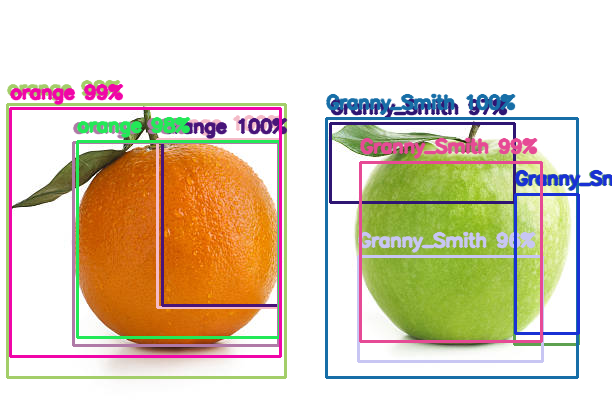

Imagen guardada como 'resultado_detecciones.jpg'


In [6]:
# Mostramos la imagen resultante con las cajas y etiquetas.
# cv2_imshow espera formato BGR, que es justo el formato de imagen_detecciones.
cv2_imshow(imagen_detecciones)

# Guardamos el resultado en un archivo para descargarlo.
cv2.imwrite('resultado_detecciones.jpg', imagen_detecciones)
print("Imagen guardada como 'resultado_detecciones.jpg'")